# 01 - EDA Forecasting

Paso 1: entender la calidad y comportamiento de la serie antes de modelar.

In [5]:
from pathlib import Path
import sys
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'data_source.py').exists():
    ROOT = ROOT.parent
if not (ROOT / 'src' / 'data_source.py').exists():
    raise RuntimeError('Abre notebook dentro de 03_modelado/forecasting_tesis_v2')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_source import load_monthly_dataset
from src.eda import quality_summary, product_volatility

In [6]:
df = load_monthly_dataset(source='dwh', fallback_quickbooks=True)
display(quality_summary(df))
display(df.head())

F:\proyecto-integrador\Avance 2\03_modelado\forecasting_tesis_v2\src\data_source.py:68: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(


,rows,productos,periodos,duplicados_producto_periodo,null_qty_fabricada,null_qty_planificada
0,12381,1002,21,0,0,0


,producto,periodo,qty_planificada,qty_fabricada,n_ordenes
0,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024-07-01,8110.0,6960.0,5
1,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024-08-01,7840.0,5440.0,2
2,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024-09-01,6811.0,6426.0,7
3,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024-10-01,10080.0,8439.0,11
4,1 CONDIMENSA > ACEITES Y GRASAS > ACEITE DE GI...,2024-11-01,8720.0,7770.0,8


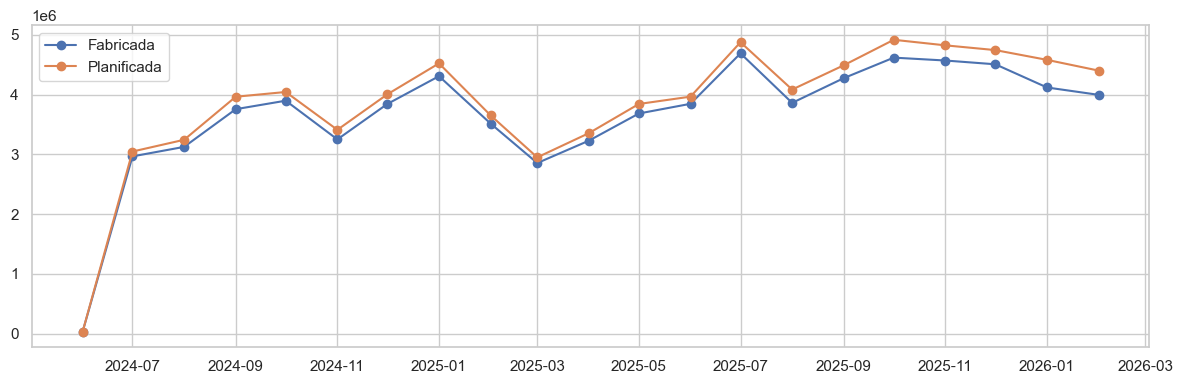

In [7]:
m = df.groupby('periodo', as_index=False)[['qty_fabricada','qty_planificada']].sum()
plt.figure(figsize=(12,4))
plt.plot(m['periodo'], m['qty_fabricada'], marker='o', label='Fabricada')
plt.plot(m['periodo'], m['qty_planificada'], marker='o', label='Planificada')
plt.legend(); plt.tight_layout(); plt.show()

In [8]:
vol = product_volatility(df)
display(vol.head(20))

,producto,media_fabricada,std_fabricada,periodos,cv_fabricada
0,ALINO COMPLETO KILOS GRANEL,192897.416667,121425.764036,12,0.629484
1,ENG ACHIOTE PASTA DP X 30(0.10),181389.750000,46478.028326,20,0.256233
2,CEBOLLA PAITEÑA PELADA,112135.916667,74575.198167,12,0.665043
3,ENG ALIÑO DP X 30 (0.10),95667.631579,39624.156856,19,0.414186
4,ACEITE PALMA _SOYA 70/30 LITROS,93584.750000,42222.206387,8,0.451165
5,ENG CANELA RAMA DISP X 15 (0.20,90031.538462,23513.253655,13,0.261167
6,ENG BICARBONATO X 30 (0.15),84078.500000,19870.519892,20,0.236333
7,MAQUILA SUPERMAXI > EL ARTESANAL ACEITE VEGETA...,82871.777778,29195.393137,9,0.352296
8,ENG CANELA RAMA DISP X 30 (0.15,78237.500000,29593.239455,8,0.378249
9,SAZON COMPLETA KILOS GRANEL,63430.366667,10009.103304,15,0.157797
